# 2.5 Visualizing Relationships Between Groups Lab

This notebook explores how applicant features relate to `loan_status` in the loan application dataset. In this dataset, `loan_status = 1` means the loan was approved and `loan_status = 0` means the loan was rejected.

The lab requires visualizing age, sex, and at least five other features with loan status. I visualized all available applicant features so the final conclusions are easier to support.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the loan application data
df = pd.read_csv('loan_data.csv')

# Show the first rows and confirm the data loaded correctly
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,71,male,Associate,46817.176426,3,RENT,11567.737650,MEDICAL,10.351469,0.247083,5,806.869094,No,0
1,34,male,High School,79093.494008,17,OWN,9519.674498,MEDICAL,11.168902,0.120360,1,604.330171,No,0
2,80,male,Associate,67819.614431,20,OWN,16226.604002,PERSONAL,12.293112,0.239261,11,685.933579,No,0
3,40,female,Associate,49599.861220,0,RENT,15641.221708,VENTURE,10.327926,0.315348,14,629.190150,No,0
4,43,male,Doctorate,99833.900180,8,OWN,12727.942517,EDUCATION,9.338069,0.127491,16,638.298168,No,1


In [2]:
# Check column names, data types, and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  int64  
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  int64  
 11  credit_score                    45000 non-null  float64
 12  previous_loan_defaults_on_file  

## Overall loan approval rate

In [3]:
overall_rate = df['loan_status'].mean()
print(f"Overall approval rate: {overall_rate:.2%}")
df['loan_status'].value_counts().sort_index()

Overall approval rate: 10.87%


loan_status
0    40107
1     4893
Name: count, dtype: int64

## Helper functions for visualizations

For quantitative features, I used boxplots grouped by loan status. I did not categorize the quantitative data because the rubric says quantitative data should not be categorized.

For categorical features, I used bar charts showing the approval rate for each group.

In [4]:
def plot_quantitative_feature(column, title, ylabel):
    plt.figure(figsize=(7, 5))
    df.boxplot(column=column, by='loan_status', grid=False)
    plt.title(title)
    plt.suptitle('')
    plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
    plt.ylabel(ylabel)
    plt.show()


def plot_categorical_feature(column, title, xlabel):
    approval_rates = df.groupby(column)['loan_status'].mean().sort_values(ascending=False)
    plt.figure(figsize=(9, 5))
    approval_rates.plot(kind='bar')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Approval Rate')
    plt.ylim(0, max(approval_rates.max() + 0.05, 0.15))
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## Quantitative features compared with loan status

<Figure size 700x500 with 0 Axes>

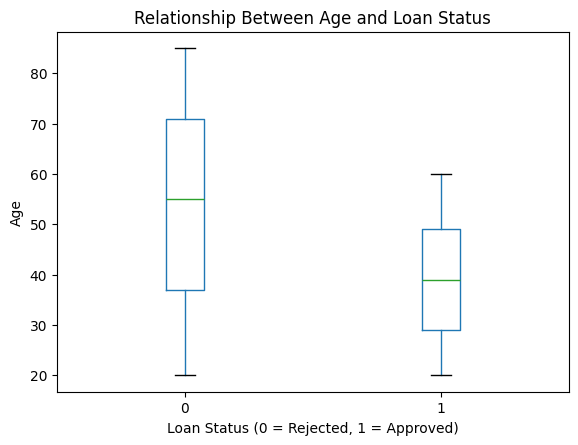

In [5]:
plot_quantitative_feature('person_age', 'Relationship Between Age and Loan Status', 'Age')

<Figure size 700x500 with 0 Axes>

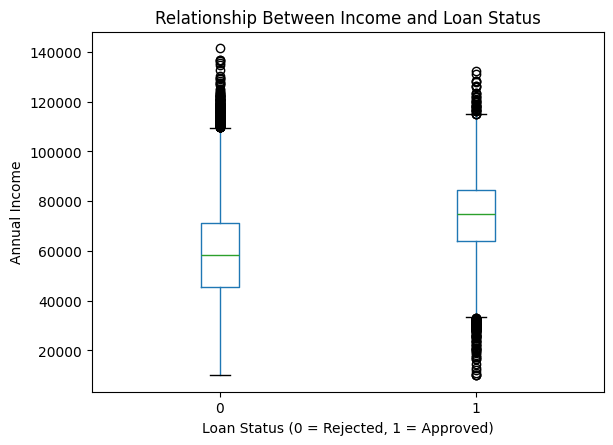

In [6]:
plot_quantitative_feature('person_income', 'Relationship Between Income and Loan Status', 'Annual Income')

<Figure size 700x500 with 0 Axes>

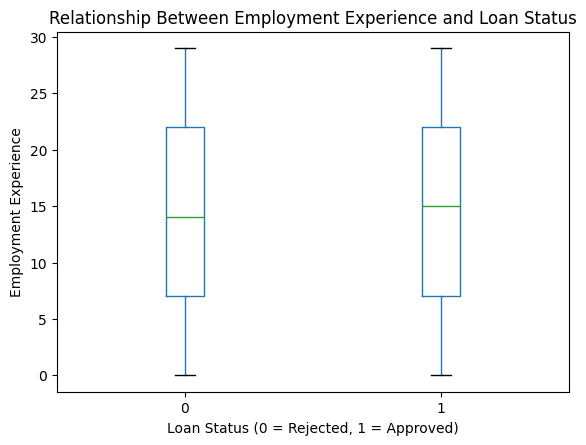

In [7]:
plot_quantitative_feature('person_emp_exp', 'Relationship Between Employment Experience and Loan Status', 'Employment Experience')

<Figure size 700x500 with 0 Axes>

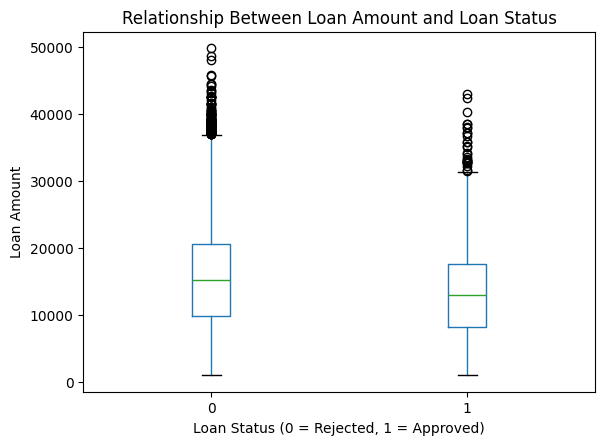

In [8]:
plot_quantitative_feature('loan_amnt', 'Relationship Between Loan Amount and Loan Status', 'Loan Amount')

<Figure size 700x500 with 0 Axes>

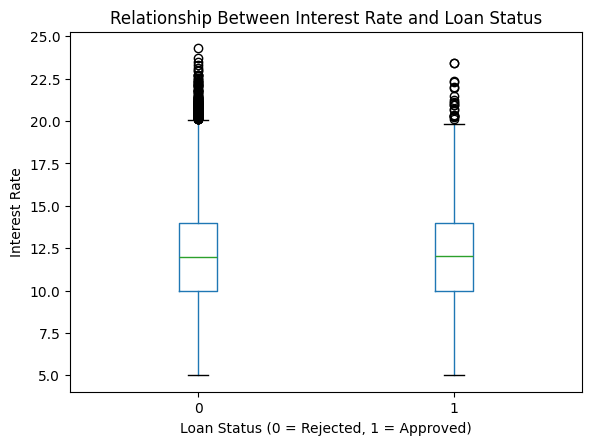

In [9]:
plot_quantitative_feature('loan_int_rate', 'Relationship Between Interest Rate and Loan Status', 'Interest Rate')

<Figure size 700x500 with 0 Axes>

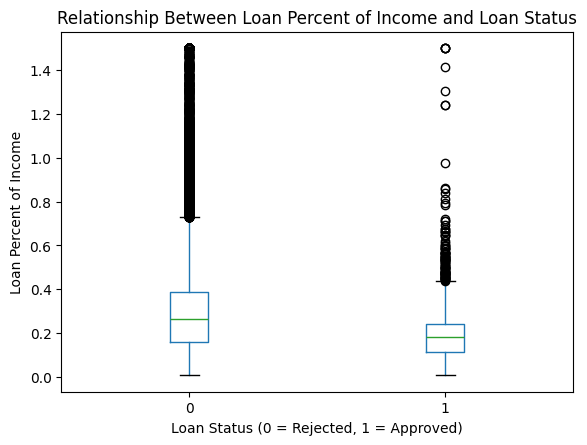

In [10]:
plot_quantitative_feature('loan_percent_income', 'Relationship Between Loan Percent of Income and Loan Status', 'Loan Percent of Income')

<Figure size 700x500 with 0 Axes>

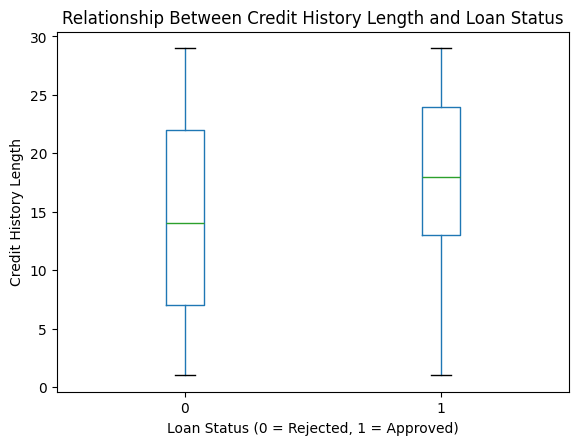

In [11]:
plot_quantitative_feature('cb_person_cred_hist_length', 'Relationship Between Credit History Length and Loan Status', 'Credit History Length')

<Figure size 700x500 with 0 Axes>

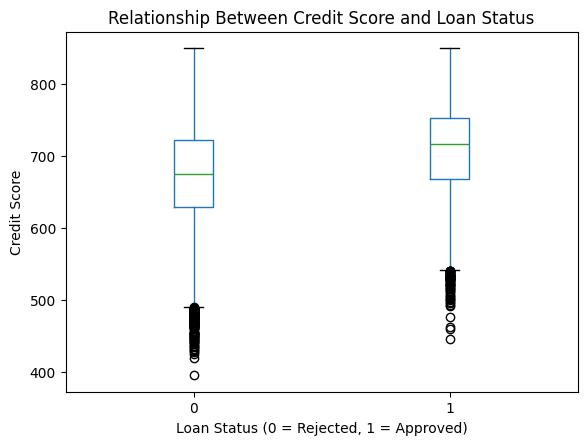

In [12]:
plot_quantitative_feature('credit_score', 'Relationship Between Credit Score and Loan Status', 'Credit Score')

## Categorical features compared with loan status

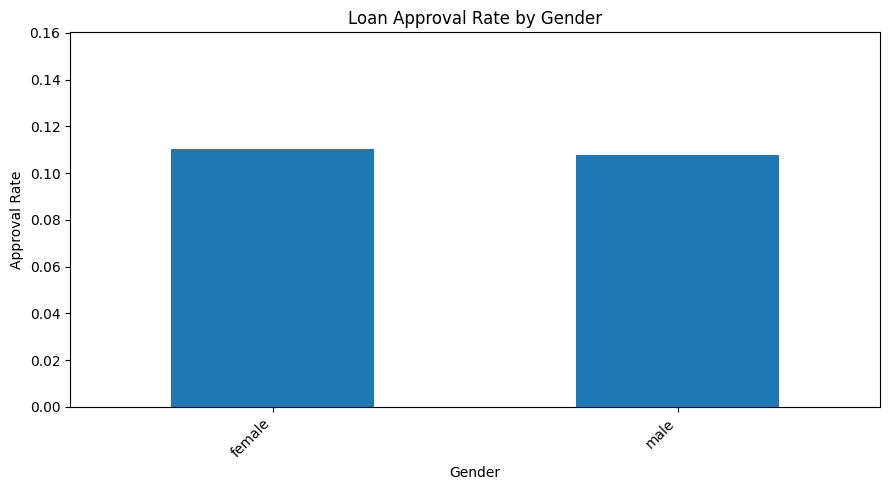

In [13]:
plot_categorical_feature('person_gender', 'Loan Approval Rate by Gender', 'Gender')

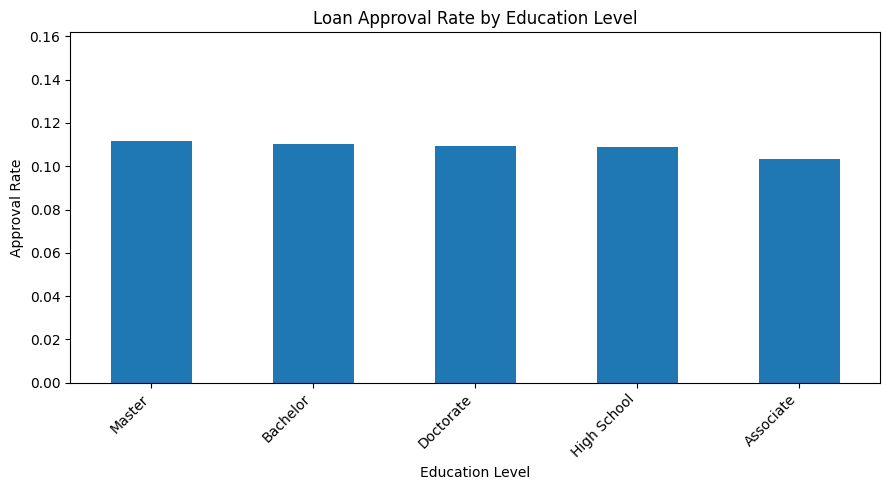

In [14]:
plot_categorical_feature('person_education', 'Loan Approval Rate by Education Level', 'Education Level')

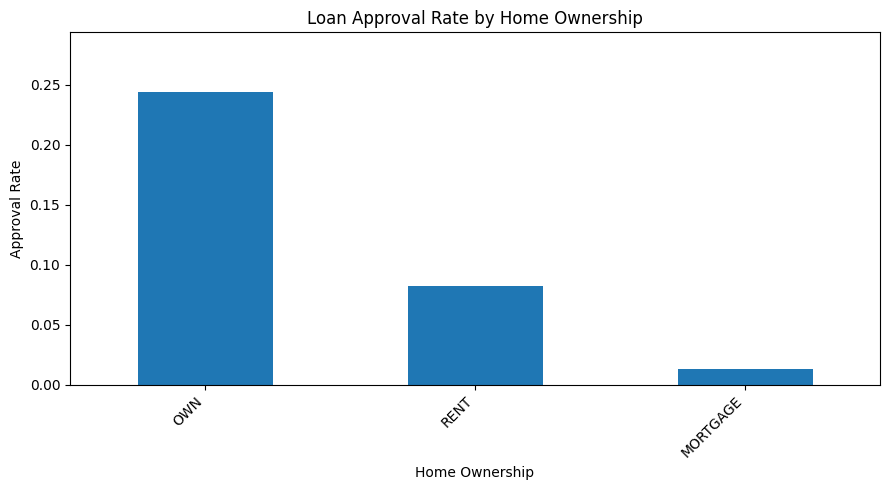

In [15]:
plot_categorical_feature('person_home_ownership', 'Loan Approval Rate by Home Ownership', 'Home Ownership')

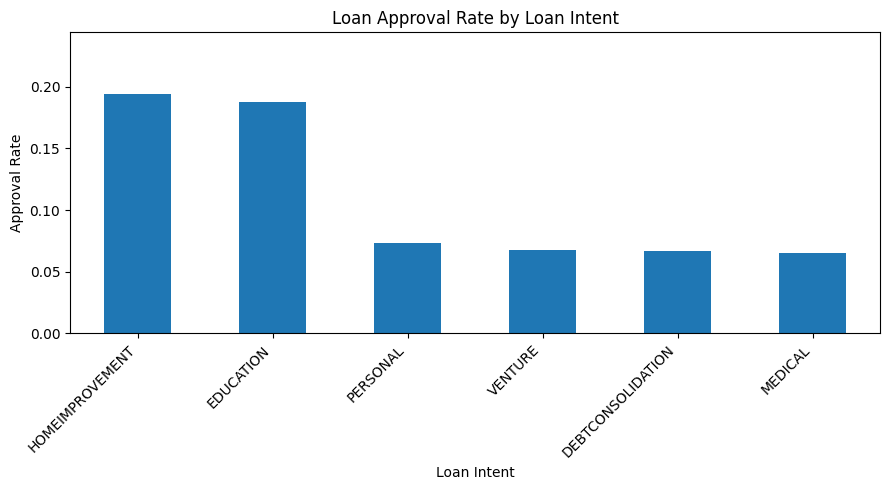

In [16]:
plot_categorical_feature('loan_intent', 'Loan Approval Rate by Loan Intent', 'Loan Intent')

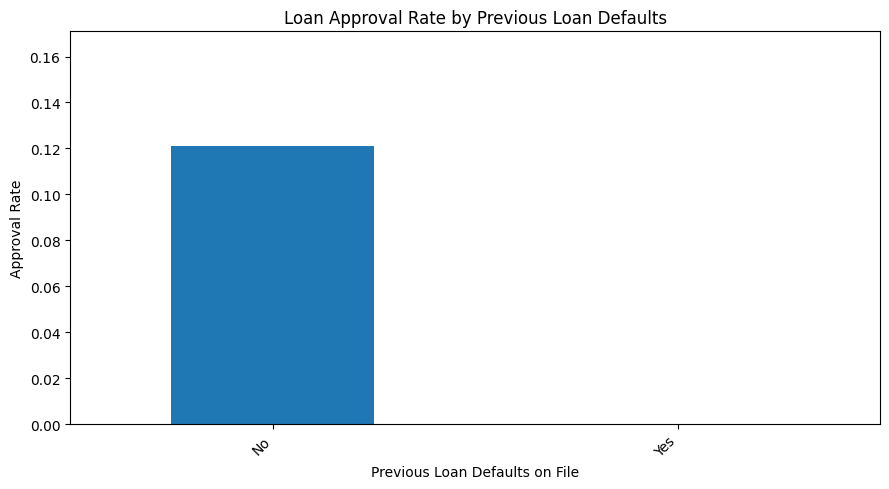

In [17]:
plot_categorical_feature('previous_loan_defaults_on_file', 'Loan Approval Rate by Previous Loan Defaults', 'Previous Loan Defaults on File')

## Relationship summary tables

In [18]:
quantitative_features = [
    'person_age',
    'person_income',
    'person_emp_exp',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length',
    'credit_score'
]

quantitative_summary = df.groupby('loan_status')[quantitative_features].mean().T
quantitative_summary.columns = ['Rejected Mean', 'Approved Mean']
quantitative_summary['Difference Approved - Rejected'] = quantitative_summary['Approved Mean'] - quantitative_summary['Rejected Mean']
quantitative_summary.sort_values('Difference Approved - Rejected', ascending=False)

,Rejected Mean,Approved Mean,Difference Approved - Rejected
person_income,58528.531356,73514.758800,14986.227444
credit_score,676.202446,709.749597,33.547151
cb_person_cred_hist_length,14.669210,17.942980,3.273770
person_emp_exp,14.440771,14.649499,0.208728
loan_int_rate,12.002137,12.009495,0.007359
loan_percent_income,0.305799,0.184616,-0.121183
person_age,54.021318,39.482117,-14.539201
loan_amnt,15386.228851,13027.322609,-2358.906242


In [19]:
categorical_features = [
    'person_gender',
    'person_education',
    'person_home_ownership',
    'loan_intent',
    'previous_loan_defaults_on_file'
]

for column in categorical_features:
    print()
    print(column)
    print(df.groupby(column)['loan_status'].mean().sort_values(ascending=False))


person_gender
person_gender
female    0.110280
male      0.107711
Name: loan_status, dtype: float64

person_education
person_education
Master         0.111856
Bachelor       0.110379
Doctorate      0.109492
High School    0.108767
Associate      0.103155
Name: loan_status, dtype: float64

person_home_ownership
person_home_ownership
OWN         0.243471
RENT        0.082253
MORTGAGE    0.013035
Name: loan_status, dtype: float64

loan_intent
loan_intent
HOMEIMPROVEMENT      0.193946
EDUCATION            0.187291
PERSONAL             0.073404
VENTURE              0.067453
DEBTCONSOLIDATION    0.066578
MEDICAL              0.065057
Name: loan_status, dtype: float64

previous_loan_defaults_on_file
previous_loan_defaults_on_file
No     0.120967
Yes    0.000000
Name: loan_status, dtype: float64


## Conclusions

The features that appear most related to a loan being approved are home ownership, age, income, loan percent of income, credit score, credit history length, previous loan defaults, and loan intent.

Home ownership has a strong relationship with loan status. Applicants who own their home have a much higher approval rate than applicants with a mortgage or rent status. Previous loan defaults also appear important because applicants with previous defaults had a much lower approval rate.

Among the quantitative features, approved applicants tended to have higher income, higher credit scores, longer credit histories, and lower loan percent of income. Approved applicants were also younger on average than rejected applicants. Loan percent of income appears important because the approved group had lower values, meaning the requested loan took up a smaller share of annual income.

The features that appear least related to loan approval are gender, education level, employment experience, and interest rate. Gender had almost no visible difference in approval rate, which suggests that sex does not appear to drive the model's decision in this dataset. Education level also showed only small differences compared with stronger features like home ownership, income, credit score, and loan percent of income.

Based on the charts, the model appears to be driven more by financial risk indicators than by gender. Age shows a stronger relationship than gender because approved applicants were noticeably younger on average, but age may also be connected to other financial variables such as income, credit history length, and loan percent of income.